# Fractional Cover Analysis 

Fractional cover is a measurement that splits the landscape into three parts, or fractions:
- green (leaves, grass, and growing crops)
- non-green or brown (branches, dry grass or hay, and dead leaf litter)
- bare ground (soil or rock)

Applications :

Fractional cover provides valuable information for a range of environmental and agricultural applications, including:

- flood detection
- natural disaster impact detection (after cyclone for example)
- land management practices (e.g. crop harvest detection)
- land cover mapping
- vegetation studies
- ecosystem modelling
- soil erosion monitoring 

Example : 

- retreiving maize
- highlight Urban Heat Island (computating Latent Heat from fc)

This notebook presents an analysis of the Fractional Cover (FC) product over different types of landscapes, with the aim to explore the capabilities and limitations of the FC product for land cover classification, ecosystem monitoring, and crop analysis. The study is structured around three main areas of interest:

**1) Urban Environment – Nouméa (New Caledonia) :** We first assess the FC product’s performance in an urban context to explore how well it can distinguish built-up areas from vegetated or bare surfaces.

**2) Natural Ecosystems – Poé and Presqu’île de Népoui (New Caledonia) :** The second part focuses on identifying native dry forest (forêt sèche), a unique and endangered ecosystem in New Caledonia. We examine whether FC metrics can differentiate this specific vegetation type from surrounding natural or degraded vegetation.

**3) Agricultural Landscapes – Vanuatu:** Finally, the FC product is analyzed in agricultural zones to evaluate its potential for crop monitoring. The goal is to assess whether FC allows us to distinguish between different crop types and identify crop growth stages.



In [1]:
import datacube
from datetime import datetime
from datetime import timedelta
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as Patch
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap
import rasterio
from rasterio.transform import from_bounds
from rasterio.crs import CRS
import geopandas as gpd
from shapely import geometry
from rasterio.transform import from_origin
from rasterio.mask import mask
from rasterio.features import rasterize
from affine import Affine

import sys
from pystac_client import Client
import depal_ck as dep
from odc.stac import load

In [2]:
from dea_tools.dask import create_local_dask_cluster
client = create_local_dask_cluster(return_client=True)


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/philippinel@spc.int/proxy/8787/status,
Dashboard: /user/philippinel@spc.int/proxy/8787/status,Workers: 1
Total threads: 8,Total memory: 57.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44361,Workers: 0
Dashboard: /user/philippinel@spc.int/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36549,Total threads: 8
Dashboard: /user/philippinel@spc.int/proxy/45859/status,Memory: 57.21 GiB
Nanny: tcp://127.0.0.1:35009,


In [3]:
catalog = "https://stac.staging.digitalearthpacific.io"

client = Client.open(catalog)

collections = client.get_collections()

for collection in collections:
    print(collection.id)

dep_ls_wofs
dep_ls_fc
dep_ls_fc_summary_annual
dep_s2_geomad
dep_s1_mosaic
dep_ls_geomad
dep_s2_mangroves
dep_ls_wofs_summary_annual
dep_s2ls_intertidal
dep_ls_wofs_summary_alltime
dep_ls_wofl
dep_s1_geomad
dep_s2_sdb
dep_s2_ocm
dep_s2s1_mrd


In [4]:
landsat = client.get_collection("dep_ls_fc")
pd.DataFrame(landsat.summaries.get_list("eo:bands"))


,max,min,name,nodata,common_name,description
0,127,0,bs,255,bare_soil,Bare soil percentage
1,127,0,pv,255,photosynthetic_veg,Photosynthetic (green) vegetation percentage
2,127,0,npv,255,non_photosynthetic_veg,Non-photosynthetic (non-green) vegetation percentage
3,127,0,ue,255,unmixing_error,Unmixing error


## 1) Urban Environment - Nouméa, New Calédonia  

In this part, the different band are pre-process in order to remove cloud before creating the composite image RGB using the different bands (bs, pv, npv) and then using a k-means clustering the land cover is computed.

In [5]:
noumea= dep.get_country_admin_boundary("New Caledonia", "Commune", "Nouméa")

In [6]:
bbox = dep.get_bbox(noumea)
bbox_geometry = geometry.box(*bbox)

gdf = gpd.GeoDataFrame({'geometry': [bbox_geometry]}, crs='EPSG:4326')
gdf.explore()

In [7]:
items = client.search(collections=["dep_ls_fc"], bbox=bbox).item_collection()
print(f"Found {len(items)} items")

Found 138 items


In [8]:
items = client.search(
    collections=["dep_ls_fc"],
    bbox=bbox,
).items()
chunks = dict(x=2048, y=2048)

# Load the data
data = load(items, chunks=chunks)
data = dep.do_coastal_clip(noumea, data, buffer=0.001)
print(data)

<xarray.Dataset> Size: 194MB
Dimensions:      (y: 474, x: 742, time: 138)
Coordinates:
  * y            (y) float64 4kB -2.457e+06 -2.457e+06 ... -2.471e+06 -2.471e+06
  * x            (x) float64 6kB 6.33e+05 6.331e+05 ... 6.552e+05 6.553e+05
  * time         (time) datetime64[ns] 1kB 2024-01-03T22:57:20.821440 ... 202...
    spatial_ref  int64 8B 0
Data variables:
    bs           (time, y, x) uint8 49MB dask.array<chunksize=(1, 266, 742), meta=np.ndarray>
    pv           (time, y, x) uint8 49MB dask.array<chunksize=(1, 266, 742), meta=np.ndarray>
    ue           (time, y, x) uint8 49MB dask.array<chunksize=(1, 266, 742), meta=np.ndarray>
    npv          (time, y, x) uint8 49MB dask.array<chunksize=(1, 266, 742), meta=np.ndarray>


In [9]:
#only keep the images where there are 95% of non-null pixels (to remove image with cloud)
band = data['pv']
fraction_255 = (band == 255).mean(dim=['x', 'y'])
mask_95_percent = fraction_255 >= 0.95
clean_data = data.sel(time=~mask_95_percent)
print(clean_data)

<xarray.Dataset> Size: 129MB
Dimensions:      (y: 474, x: 742, time: 92)
Coordinates:
  * y            (y) float64 4kB -2.457e+06 -2.457e+06 ... -2.471e+06 -2.471e+06
  * x            (x) float64 6kB 6.33e+05 6.331e+05 ... 6.552e+05 6.553e+05
  * time         (time) datetime64[ns] 736B 2024-01-04T22:51:19.166842 ... 20...
    spatial_ref  int64 8B 0
Data variables:
    bs           (time, y, x) uint8 32MB dask.array<chunksize=(1, 266, 742), meta=np.ndarray>
    pv           (time, y, x) uint8 32MB dask.array<chunksize=(1, 266, 742), meta=np.ndarray>
    ue           (time, y, x) uint8 32MB dask.array<chunksize=(1, 266, 742), meta=np.ndarray>
    npv          (time, y, x) uint8 32MB dask.array<chunksize=(1, 266, 742), meta=np.ndarray>


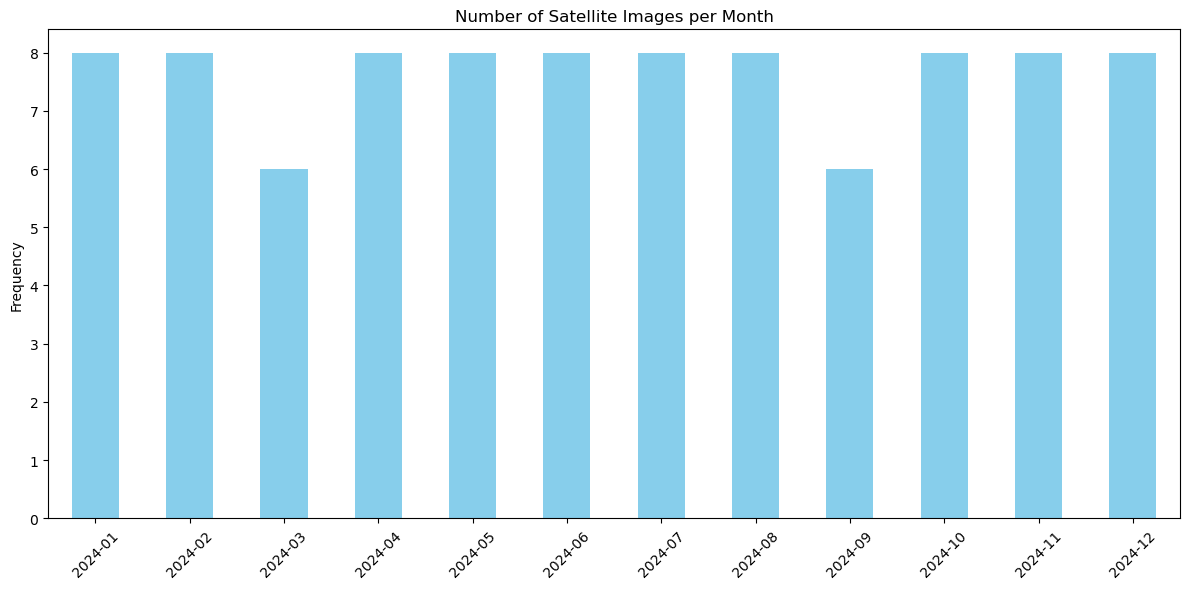

In [10]:
# Plot the frequency of image per month
time_values = pd.to_datetime(clean_data.time.values)

monthly_counts = time_values.to_series().dt.to_period("M").value_counts().sort_index()

monthly_counts.plot(kind='bar', figsize=(12, 6), color='skyblue')
plt.title("Number of Satellite Images per Month")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

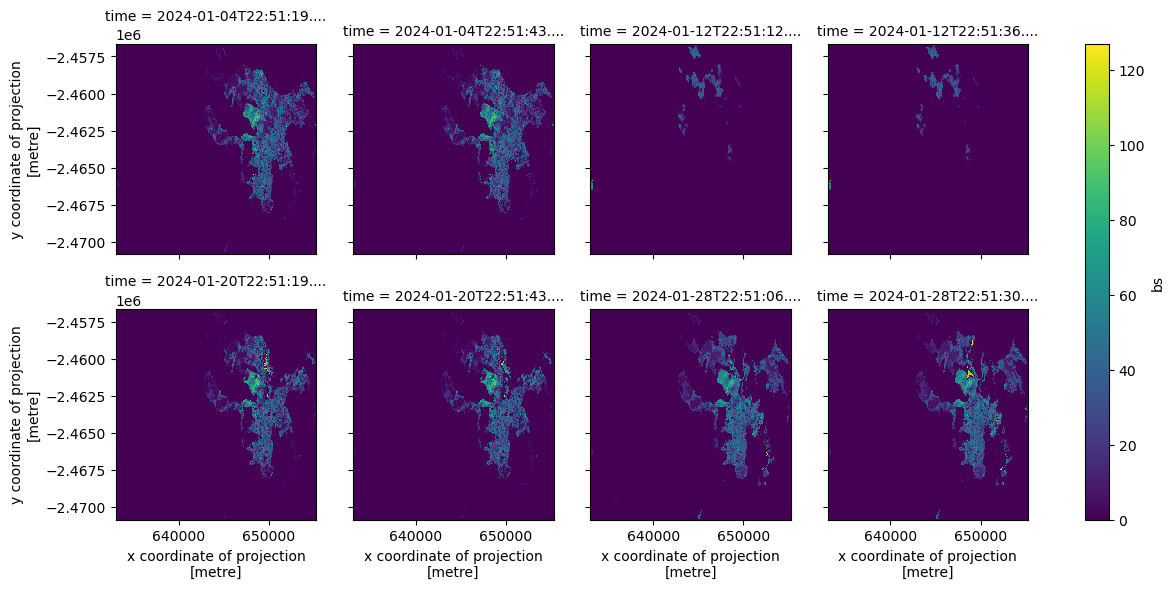

In [11]:
# Visualize image for one month
jan_data = clean_data.sel(time=clean_data.time.dt.month == 1)
jan_data = jan_data['bs']
jan_data = jan_data.where(jan_data != 255, 0) #set cloud to 0 insted of 255
dep.visualise(jan_data)

Globally, we have between 3 and 4 landsat images (plots show 6 and 8 because for each time two images are taken 30seconds apart)

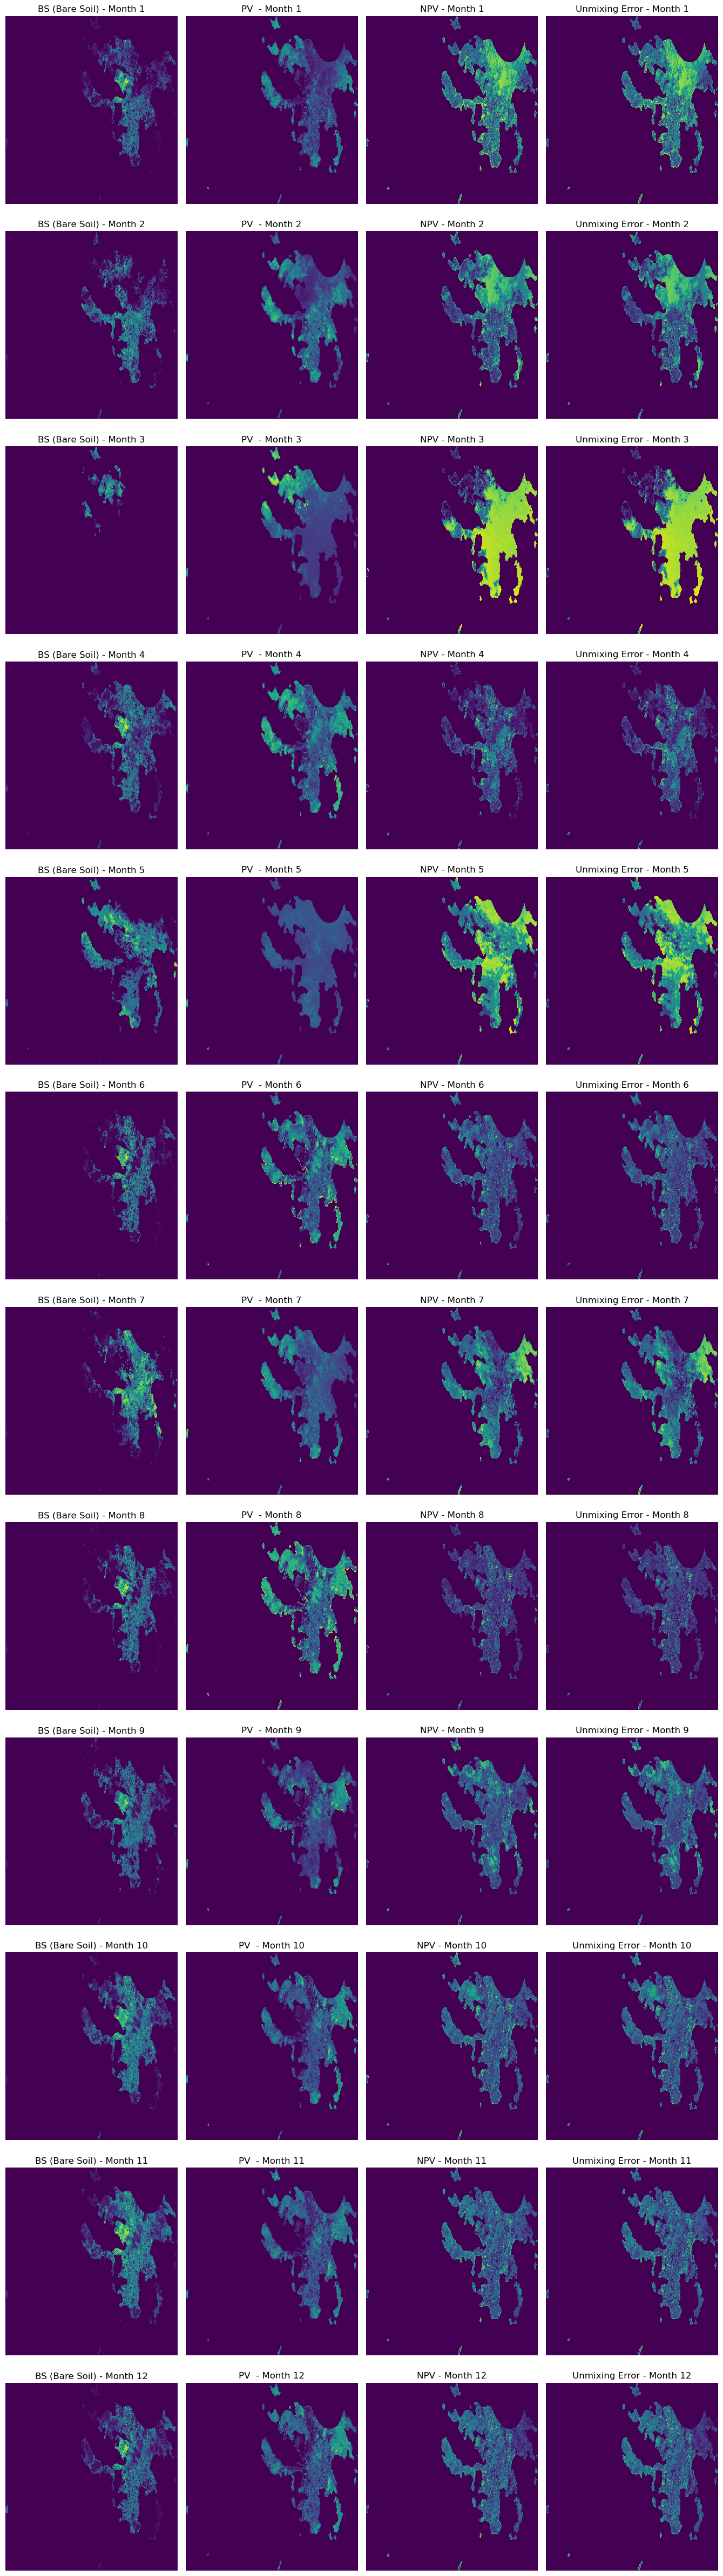

In [12]:
#Visualize the different band for each month (median of the band per month)
data = clean_data
data = data.where(data != 255, 0)

monthly_bs = ((data['bs'] / 255) * 100).groupby(data.time.dt.month).median(dim='time')
monthly_pv = ((data['pv'] / 255) * 100).groupby(data.time.dt.month).median(dim='time')
monthly_npv = ((data['npv'] / 255) * 100).groupby(data.time.dt.month).median(dim='time')
monthly_ue = ((data['npv'] / 255) * 127).groupby(data.time.dt.month).median(dim='time')

monthly_bands = [monthly_bs, monthly_pv, monthly_npv, monthly_ue]
band_titles = ['BS (Bare Soil)', 'PV ', 'NPV', 'Unmixing Error']

available_months = monthly_bs['month'].values

fig, axes = plt.subplots(nrows=12, ncols=4, figsize=(15, 48))

example_images = [None, None, None, None]

for i, month in enumerate(range(1, 13)):  
    for j in range(4):  
        ax = axes[i, j]
        if month in available_months:
            img = monthly_bands[j].sel(month=month)
            plot = img.plot(ax=ax, add_colorbar=False, cmap='viridis')
            if example_images[j] is None:
                example_images[j] = plot  
            ax.set_title(f"{band_titles[j]} - Month {month}")
        else:
            ax.set_visible(False)
        ax.axis('off')


plt.tight_layout(rect=[0, 0, 0.9, 1]) 
plt.show()

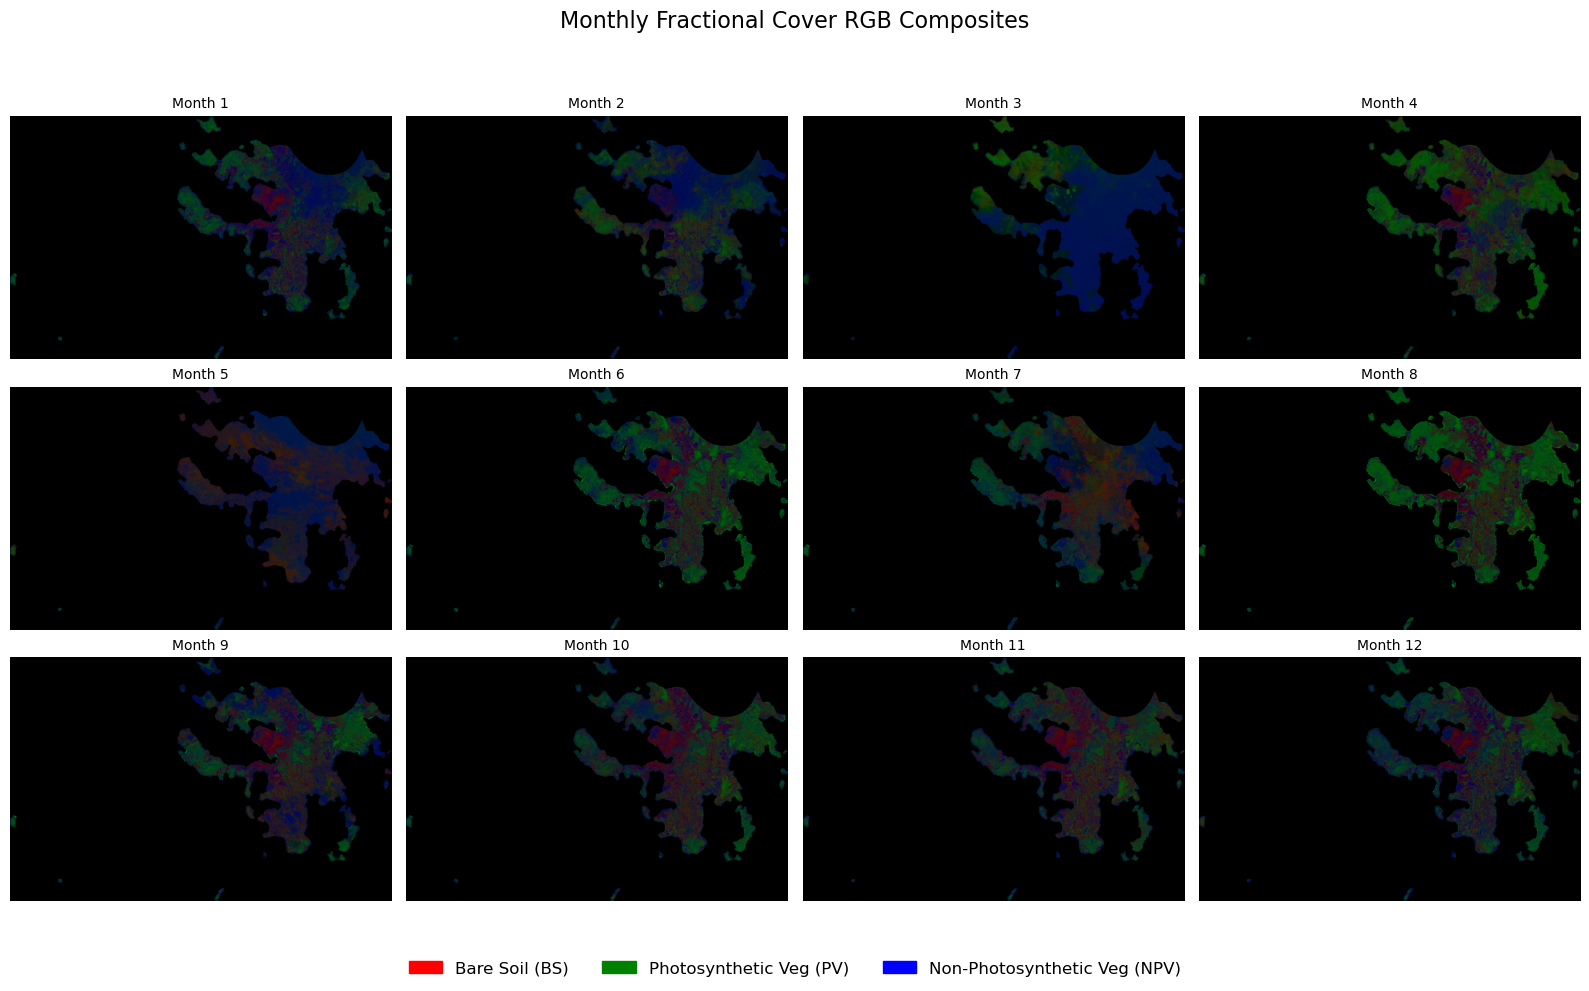

In [13]:
# Create RGB composite imagery
data = clean_data
data = data.where(data != 255, 0)

monthly_bs = ((data['bs'] / 255) * 100).groupby(data.time.dt.month).median(dim='time')
monthly_pv = ((data['pv'] / 255) * 100).groupby(data.time.dt.month).median(dim='time')
monthly_npv = ((data['npv'] / 255) * 100).groupby(data.time.dt.month).median(dim='time')

monthly_bands = [monthly_bs, monthly_pv, monthly_npv]
band_titles = ['BS (Bare Soil)', 'PV (Photosynthetic Veg)', 'NPV (Non-Photosynthetic Veg)']

available_months = monthly_bs['month'].values


fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 10))
axes = axes.flatten()

for i, month in enumerate(range(1, 13)):
    ax = axes[i]
    if month in available_months:
        bs = monthly_bs.sel(month=month) / 100.0
        pv = monthly_pv.sel(month=month) / 100.0
        npv = monthly_npv.sel(month=month) / 100.0

        # Stack into RGB
        rgb_img = np.dstack([bs, pv, npv])
        rgb_img = np.clip(rgb_img, 0, 1)

        ax.imshow(rgb_img)
        ax.set_title(f"Month {month}", fontsize=10)
    else:
        ax.set_visible(False)

    ax.axis('off')

legend_patches = [
    Patch.Patch(color='red', label='Bare Soil (BS)'),
    Patch.Patch(color='green', label='Photosynthetic Veg (PV)'),
    Patch.Patch(color='blue', label='Non-Photosynthetic Veg (NPV)')
]

fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=12, frameon=False)

plt.suptitle("Monthly Fractional Cover RGB Composites", fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.95]) 
plt.show()


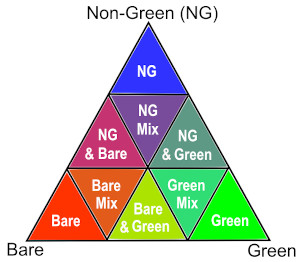

From the previous RGB composite images, we compute 9 clusters (based on the triangle above cluster) on the urban area to see if it match different land use/land cover.

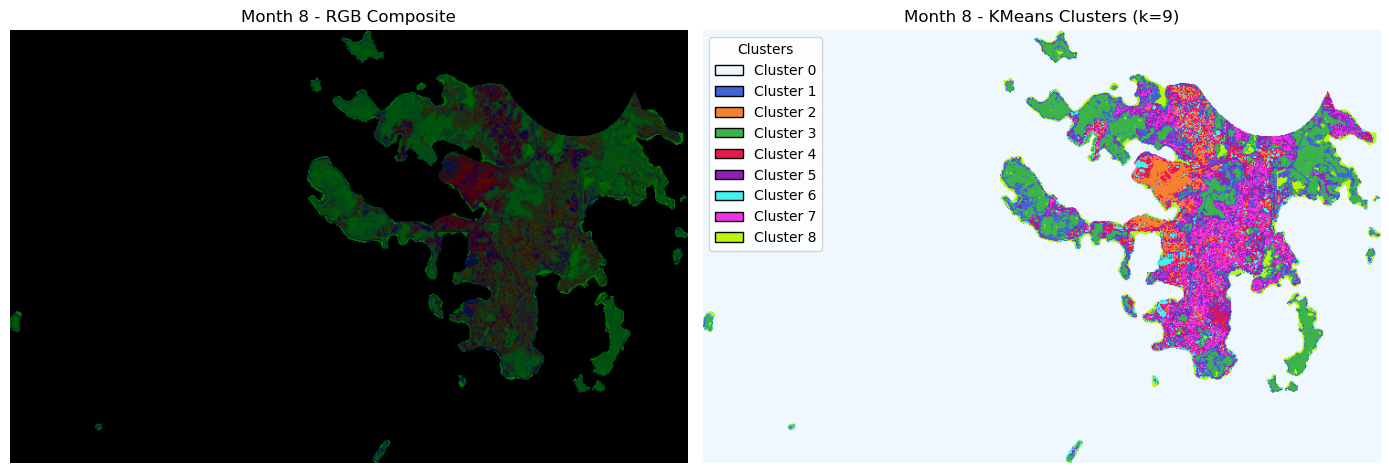

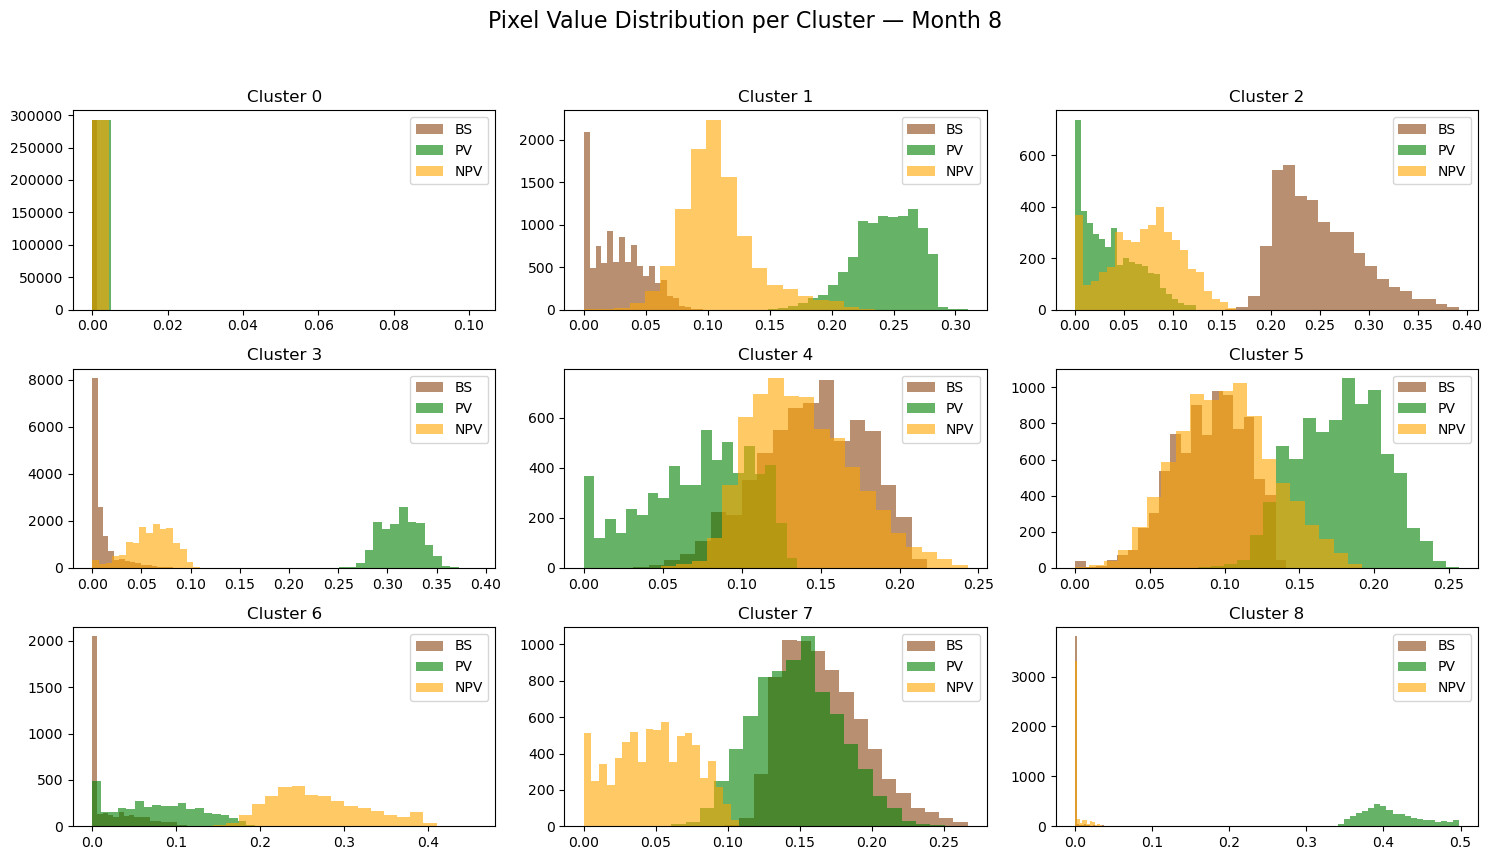

In [14]:
# --- Parameters ---
month = 8  # Choose the month
k = 9  # Number of clusters

# --- Prepare Data ---
data = clean_data.where(clean_data != 255, 0)

bs = (data['bs'] / 255 * 100).groupby('time.month').median(dim='time')
pv = (data['pv'] / 255 * 100).groupby('time.month').median(dim='time')
npv = (data['npv'] / 255 * 100).groupby('time.month').median(dim='time')

bs_m = bs.sel(month=month) / 100.0
pv_m = pv.sel(month=month) / 100.0
npv_m = npv.sel(month=month) / 100.0

# RGB composite
rgb_img = np.dstack([bs_m, pv_m, npv_m])
rgb_img = np.clip(rgb_img, 0, 1)

# Flatten and cluster
h, w, c = rgb_img.shape
flat_rgb = rgb_img.reshape(-1, 3)
valid_mask = ~np.isnan(flat_rgb).any(axis=1)
rgb_valid = flat_rgb[valid_mask]

kmeans = KMeans(n_clusters=k, random_state=42)
labels = np.full(flat_rgb.shape[0], np.nan)
labels[valid_mask] = kmeans.fit_predict(rgb_valid)
label_img = labels.reshape(h, w)

# Plot RGB + Clusters 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


axes[0].imshow(rgb_img)
axes[0].set_title(f'Month {month} - RGB Composite')
axes[0].axis('off')

fixed_colors = [
    'aliceblue', '#4363d8', '#f58231', '#3cb44b', '#e6194b',
    '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe'
]

cluster_cmap = ListedColormap(fixed_colors[:k])
axes[1].imshow(label_img, cmap=cluster_cmap)
axes[1].set_title(f'Month {month} - KMeans Clusters (k={k})')
axes[1].axis('off')

legend_elements = [
    Patch.Patch(facecolor=cluster_cmap(i), edgecolor='black', label=f'Cluster {i}')
    for i in range(k)
]
axes[1].legend(handles=legend_elements, loc='upper left', title='Clusters')
plt.tight_layout()
plt.show()


# Plot Cluster Pixel Distribution 
fig, axes = plt.subplots(nrows=int(np.ceil(k / 3)), ncols=3, figsize=(15, 3 * int(np.ceil(k / 3))))
axes = axes.flatten()

for cl in range(k):
    mask = label_img == cl

    bs_vals = bs_m.values[mask]
    pv_vals = pv_m.values[mask]
    npv_vals = npv_m.values[mask]

    ax = axes[cl]
    ax.hist(bs_vals, bins=20, alpha=0.6, label='BS', color='saddlebrown')
    ax.hist(pv_vals, bins=20, alpha=0.6, label='PV', color='green')
    ax.hist(npv_vals, bins=20, alpha=0.6, label='NPV', color='orange')
    ax.set_title(f'Cluster {cl}')
    ax.legend()

plt.suptitle(f'Pixel Value Distribution per Cluster — Month {month}', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



- Cluster 0 : no value
- Building areas = cluster 7 and 4 (large BS and either large pv or npv)
- Bare Soil = cluster 2
- Grass land = cluster 1 (large pv and medium npv)
- Forest/Tree = cluster 3 (large pv)
- Inland Water = cluster 6
- Mangroves = cluster 8 (no bs and large pv)
- cluster 5 ???

## 2) Forest Ecosystem -Poé and Népoui, New Calédonia 

In this section, we investigate whether the Fractional Cover (FC) product can be used to distinguish between different types of vegetated areas, specifically to identify dry forest (forêt sèche) in New Caledonia. A shapefile containing polygons of known dry forest areas was obtained from a government platform. The analysis was first conducted in the Poé/Deva region, which contains a significant extent of dry forest. The FC values within this area revealed that the dry forest tends to fall within a specific cluster. We extracted the mean and standard deviation statistics of this cluster for use as a reference.

To test the consistency of this signature, we selected another region known to also contain large area of dry forest: Presqu'île de Népoui. We then compared the FC values in this region to those from the reference cluster using z-scores. This allowed us to highlight potential dry forest areas in Presqu'île de Népoui and compare them with official dry forest data from the government.

In [15]:
central_lat = -21.56556270349608
central_lon = 165.35033527971385
buffer = 0.05


lower_left = (central_lat - buffer, central_lon - buffer)
upper_right = (central_lat + buffer, central_lon + buffer)

bbox = (lower_left[1], lower_left[0], upper_right[1], upper_right[0])
bbox_geometry = geometry.box(*bbox)

gdf = gpd.GeoDataFrame({'geometry': [bbox_geometry]}, crs='EPSG:4326')
gdf.explore()

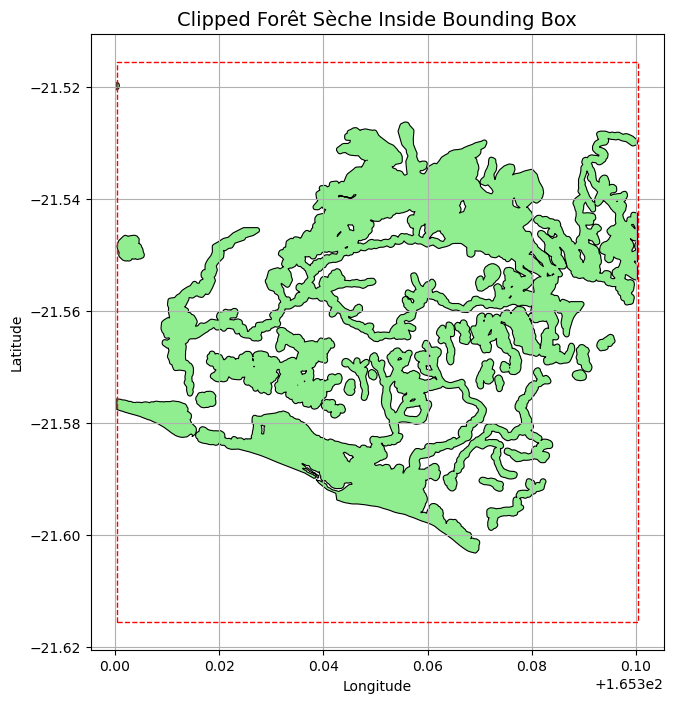

In [16]:
foret = gpd.read_file("Cartographie_des_forêts_sèches_de_Nouvelle-Calédonie_(zone_de_vigilance).shp")  
if foret.crs != "EPSG:4326":
    foret = foret.to_crs("EPSG:4326")

# Clip to bounding box (keep only what's inside)
foret_clipped = gpd.clip(foret, gdf)

# Plot result
fig, ax = plt.subplots(figsize=(10, 8))
foret_clipped.plot(ax=ax, edgecolor='black', facecolor='lightgreen', linewidth=0.8)
gdf.boundary.plot(ax=ax, color='red', linestyle='--', linewidth=1)
ax.set_title("Clipped Forêt Sèche Inside Bounding Box", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

In [17]:
items = client.search(collections=["dep_ls_fc"], bbox=bbox).item_collection()
print(f"Found {len(items)} items")

Found 46 items


In [18]:
items = client.search(
    collections=["dep_ls_fc"],
    bbox=bbox,
).items()
chunks = dict(x=2048, y=2048)

# Load the data
data = load(items, chunks=chunks)
data = dep.do_coastal_clip(gdf, data, buffer=0.001)
print(data)

<xarray.Dataset> Size: 24MB
Dimensions:      (y: 371, x: 347, time: 46)
Coordinates:
  * y            (y) float64 3kB -2.379e+06 -2.379e+06 ... -2.39e+06 -2.39e+06
  * x            (x) float64 3kB 5.311e+05 5.311e+05 ... 5.414e+05 5.415e+05
  * time         (time) datetime64[ns] 368B 2024-01-03T22:57:20.821440 ... 20...
    spatial_ref  int64 8B 0
Data variables:
    bs           (time, y, x) uint8 6MB dask.array<chunksize=(1, 371, 347), meta=np.ndarray>
    pv           (time, y, x) uint8 6MB dask.array<chunksize=(1, 371, 347), meta=np.ndarray>
    ue           (time, y, x) uint8 6MB dask.array<chunksize=(1, 371, 347), meta=np.ndarray>
    npv          (time, y, x) uint8 6MB dask.array<chunksize=(1, 371, 347), meta=np.ndarray>


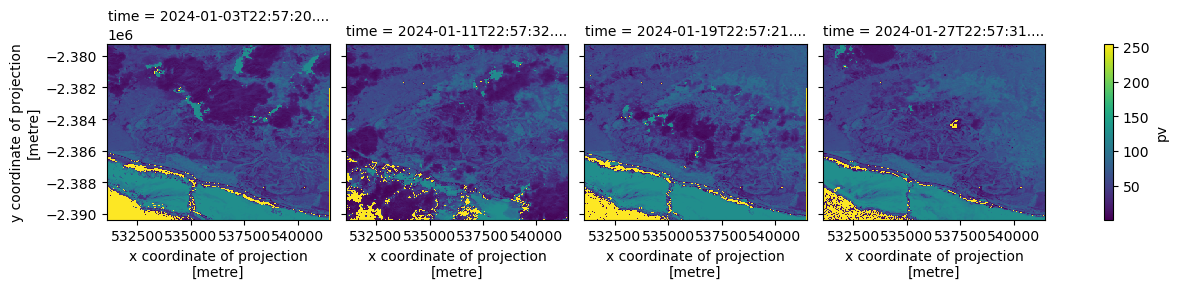

In [19]:
jan_data = data.sel(time=data.time.dt.month == 1)
jan_data = jan_data['pv']

dep.visualise(jan_data)

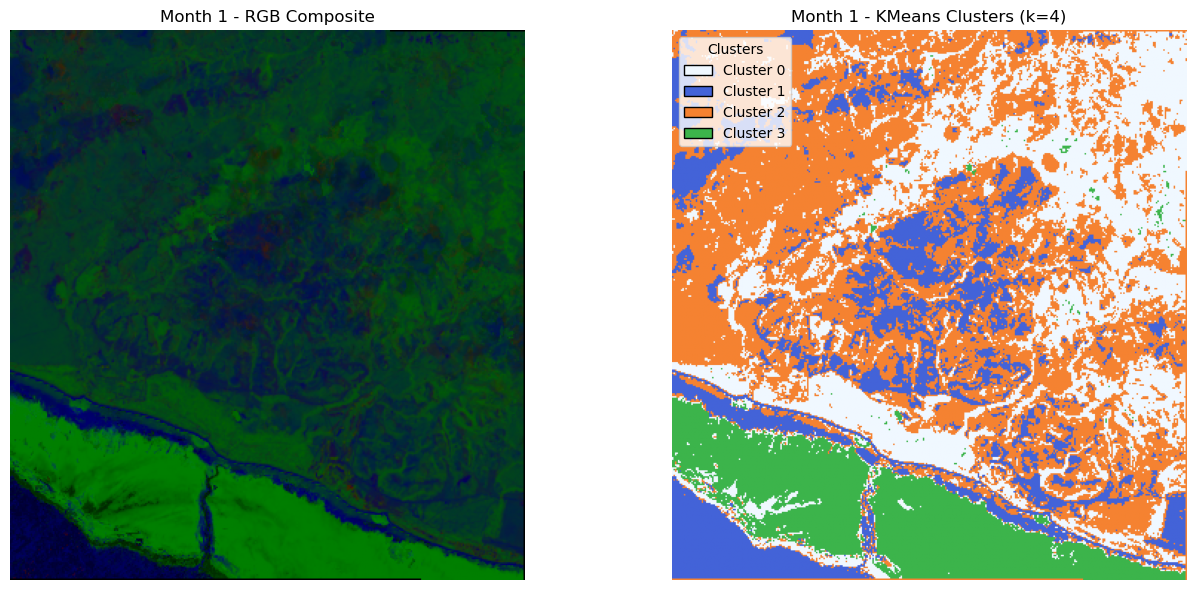

In [20]:
# Compute cluster for area of Poé

# --- Parameters ---
month = 1  
k = 4 

# --- Prepare Data ---
data = data.where(data != 255, 0)

bs = (data['bs'] / 255 * 100).groupby('time.month').median(dim='time')
pv = (data['pv'] / 255 * 100).groupby('time.month').median(dim='time')
npv = (data['npv'] / 255 * 100).groupby('time.month').median(dim='time')

bs_m = bs.sel(month=month) / 100.0
pv_m = pv.sel(month=month) / 100.0
npv_m = npv.sel(month=month) / 100.0

# RGB composite
rgb_img = np.dstack([bs_m, pv_m, npv_m])
rgb_img = np.clip(rgb_img, 0, 1)

# Flatten and cluster
h, w, c = rgb_img.shape
flat_rgb = rgb_img.reshape(-1, 3)
valid_mask = ~np.isnan(flat_rgb).any(axis=1)
rgb_valid = flat_rgb[valid_mask]

kmeans = KMeans(n_clusters=k, random_state=42)
labels = np.full(flat_rgb.shape[0], np.nan)
labels[valid_mask] = kmeans.fit_predict(rgb_valid)
label_img = labels.reshape(h, w)

# Plot RGB + Clusters 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


axes[0].imshow(rgb_img)
axes[0].set_title(f'Month {month} - RGB Composite')
axes[0].axis('off')

fixed_colors = [
    'aliceblue', '#4363d8', '#f58231', '#3cb44b', '#e6194b',
    '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe'
]

cluster_cmap = ListedColormap(fixed_colors[:k])
axes[1].imshow(label_img, cmap=cluster_cmap)
axes[1].set_title(f'Month {month} - KMeans Clusters (k={k})')
axes[1].axis('off')

legend_elements = [
    Patch.Patch(facecolor=cluster_cmap(i), edgecolor='black', label=f'Cluster {i}')
    for i in range(k)
]
axes[1].legend(handles=legend_elements, loc='upper left', title='Clusters')
plt.tight_layout()
plt.show()

Dry Forest correspond to mainly to the cluster 0

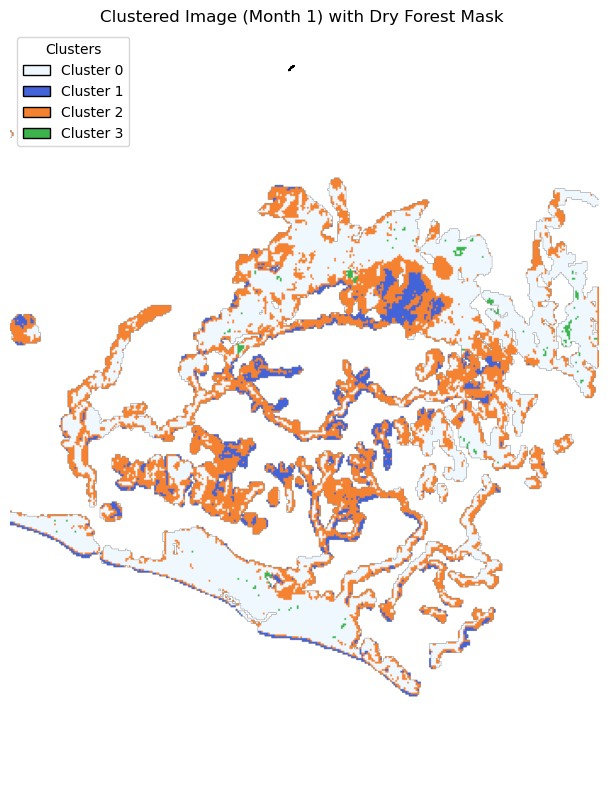

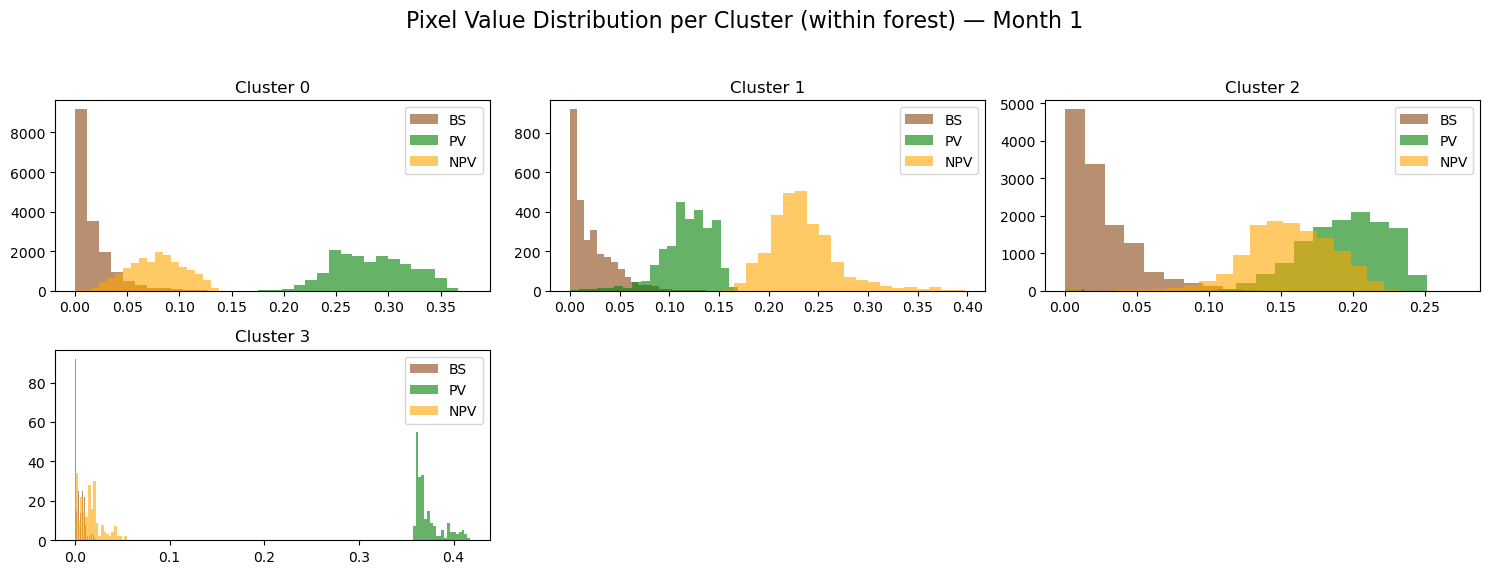

In [23]:
from rasterio.mask import mask

# Keep only the mask of the dry forest (from .shp) to run the pixel distribution analysis
# --- Parameters ---
month = 1
k = 4
central_lat = -21.56556270349608
central_lon = 165.35033527971385
buffer = 0.05
extent = [central_lon - buffer, central_lat - buffer, central_lon + buffer, central_lat + buffer] 

# --- Load and Prepare Data ---
bs = (data['bs'] / 255 * 100).groupby('time.month').median(dim='time')
pv = (data['pv'] / 255 * 100).groupby('time.month').median(dim='time')
npv = (data['npv'] / 255 * 100).groupby('time.month').median(dim='time')

bs_m = bs.sel(month=month) / 100.0
pv_m = pv.sel(month=month) / 100.0
npv_m = npv.sel(month=month) / 100.0

# RGB composite
rgb_img = np.dstack([bs_m, pv_m, npv_m])
rgb_img = np.clip(rgb_img, 0, 1)
h, w, c = rgb_img.shape

# --- KMeans Clustering ---
flat_rgb = rgb_img.reshape(-1, 3)
valid_mask = ~np.isnan(flat_rgb).any(axis=1)
rgb_valid = flat_rgb[valid_mask]

kmeans = KMeans(n_clusters=k, random_state=42)
labels = np.full(flat_rgb.shape[0], np.nan)
labels[valid_mask] = kmeans.fit_predict(rgb_valid)
label_img = labels.reshape(h, w)

# --- Create GeoTransform ---
res_lon = (extent[2] - extent[0]) / w
res_lat = (extent[3] - extent[1]) / h
transform = from_origin(extent[0], extent[3], res_lon, res_lat)
crs = "EPSG:4326"

# --- Load and Clip Forest Polygon ---
foret = gpd.read_file("Cartographie_des_forêts_sèches_de_Nouvelle-Calédonie_(zone_de_vigilance).shp")
if foret.crs != crs:
    foret = foret.to_crs(crs)
geometry = [foret.unary_union]

# --- Clip Cluster Image ---
with rasterio.io.MemoryFile() as memfile:
    with memfile.open(
        driver='GTiff',
        height=h,
        width=w,
        count=1,
        dtype=label_img.dtype,
        crs=crs,
        transform=transform
    ) as dataset:
        dataset.write(label_img, 1)
        clipped_labels, clipped_transform = mask(dataset, geometry, crop=True, filled=True, nodata=np.nan)

clipped_labels = clipped_labels[0]

# --- Clip Bands to Match ---
def clip_band(band_array, transform, geometry):
    with rasterio.io.MemoryFile() as memfile:
        with memfile.open(
            driver='GTiff',
            height=h,
            width=w,
            count=1,
            dtype=band_array.dtype,
            crs=crs,
            transform=transform
        ) as dataset:
            dataset.write(band_array, 1)
            clipped, _ = mask(dataset, geometry, crop=True)
            return clipped[0]

bs_clip = clip_band(bs_m.values.astype(np.float32), transform, geometry)
pv_clip = clip_band(pv_m.values.astype(np.float32), transform, geometry)
npv_clip = clip_band(npv_m.values.astype(np.float32), transform, geometry)

# --- Plot RGB & Clusters with Boundary ---
fixed_colors = [
    'aliceblue', '#4363d8', '#f58231', '#3cb44b', '#e6194b',
    '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe'
]
cluster_cmap = ListedColormap(fixed_colors[:k])

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(clipped_labels, cmap=cluster_cmap)
foret.boundary.plot(ax=ax, color='black', linewidth=1)
ax.set_title(f"Clustered Image (Month {month}) with Dry Forest Mask ")
ax.axis('off')

# Legend
legend_elements = [
    Patch.Patch(facecolor=cluster_cmap(i), edgecolor='black', label=f'Cluster {i}')
    for i in range(k)
]
ax.legend(handles=legend_elements, loc='upper left', title='Clusters')
plt.tight_layout()
plt.show()

# --- Plot Cluster-wise Pixel Value Distributions ---
fig, axes = plt.subplots(nrows=int(np.ceil(k / 3)), ncols=3, figsize=(15, 3 * int(np.ceil(k / 3))))
axes = axes.flatten()

for cl in range(k):
    mask = clipped_labels == cl

    bs_vals = bs_clip[mask]
    pv_vals = pv_clip[mask]
    npv_vals = npv_clip[mask]

    ax = axes[cl]
    ax.hist(bs_vals, bins=20, alpha=0.6, label='BS', color='saddlebrown')
    ax.hist(pv_vals, bins=20, alpha=0.6, label='PV', color='green')
    ax.hist(npv_vals, bins=20, alpha=0.6, label='NPV', color='orange')
    ax.set_title(f'Cluster {cl}')
    ax.legend()

# Hide unused subplots if k < total slots
for i in range(k, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle(f'Pixel Value Distribution per Cluster (within forest) — Month {month}', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [24]:
# Store values of Cluster 0 (corresponding to dry forest)
cluster_0_mask = clipped_labels == 0

bs_cluster0 = bs_clip[cluster_0_mask]
pv_cluster0 = pv_clip[cluster_0_mask]
npv_cluster0 = npv_clip[cluster_0_mask]

bs_cluster0 = bs_cluster0[~np.isnan(bs_cluster0)]
pv_cluster0 = pv_cluster0[~np.isnan(pv_cluster0)]
npv_cluster0 = npv_cluster0[~np.isnan(npv_cluster0)]

# Store in a dictionary
cluster0_reference = {
    "bs": bs_cluster0,
    "pv": pv_cluster0,
    "npv": npv_cluster0
}

# Compute and store the mean/std too
cluster0_stats = {
    "bs_mean": bs_cluster0.mean(), "bs_std": bs_cluster0.std(),
    "pv_mean": pv_cluster0.mean(), "pv_std": pv_cluster0.std(),
    "npv_mean": npv_cluster0.mean(), "npv_std": npv_cluster0.std()
}
print(cluster0_stats)

{'bs_mean': 0.015510113, 'bs_std': 0.019650755, 'pv_mean': 0.2840118, 'pv_std': 0.036188878, 'npv_mean': 0.07755137, 'npv_std': 0.026324414}


Now, we have the reference statistics to detect dry forest, we download data from Népoui to run the comparison.

In [25]:
from shapely.geometry import box
# Presqu'île de Népoui - New Caledonia
central_lat = -21.331964829700752
central_lon = 164.95308493271892
buffer = 0.03


lower_left = (central_lat - buffer, central_lon - buffer)
upper_right = (central_lat + buffer, central_lon + buffer)

bbox = (lower_left[1], lower_left[0], upper_right[1], upper_right[0])
bbox_geometry = box(*bbox)

gdf = gpd.GeoDataFrame({'geometry': [bbox_geometry]}, crs='EPSG:4326')
gdf.explore()

In [26]:
items = client.search(collections=["dep_ls_fc"], bbox=bbox).item_collection()
print(f"Found {len(items)} items")

Found 91 items


In [27]:
items = client.search(
    collections=["dep_ls_fc"],
    bbox=bbox,
).items()
chunks = dict(x=2048, y=2048)

# Load the data
data = load(items, chunks=chunks)
data = dep.do_coastal_clip(gdf, data, buffer=0.001)
print(data)

<xarray.Dataset> Size: 17MB
Dimensions:      (y: 222, x: 208, time: 91)
Coordinates:
  * y            (y) float64 2kB -2.356e+06 -2.356e+06 ... -2.362e+06 -2.362e+06
  * x            (x) float64 2kB 4.92e+05 4.921e+05 ... 4.982e+05 4.982e+05
  * time         (time) datetime64[ns] 728B 2024-01-02T23:03:42.626943 ... 20...
    spatial_ref  int64 8B 0
Data variables:
    bs           (time, y, x) uint8 4MB dask.array<chunksize=(1, 222, 208), meta=np.ndarray>
    pv           (time, y, x) uint8 4MB dask.array<chunksize=(1, 222, 208), meta=np.ndarray>
    ue           (time, y, x) uint8 4MB dask.array<chunksize=(1, 222, 208), meta=np.ndarray>
    npv          (time, y, x) uint8 4MB dask.array<chunksize=(1, 222, 208), meta=np.ndarray>


In [28]:
band = data['pv']
fraction_255 = (band == 255).mean(dim=['x', 'y'])
mask_95_percent = fraction_255 >= 0.95
clean_data = data.sel(time=~mask_95_percent)

band = clean_data['pv']
fraction_255 = (band == 0).mean(dim=['x', 'y'])
mask_95_percent = fraction_255 > 0.1
clean_data = clean_data.sel(time=~mask_95_percent)
clean_data = clean_data.where(clean_data != 255, 0)
print(clean_data)

<xarray.Dataset> Size: 16MB
Dimensions:      (time: 88, y: 222, x: 208)
Coordinates:
  * y            (y) float64 2kB -2.356e+06 -2.356e+06 ... -2.362e+06 -2.362e+06
  * x            (x) float64 2kB 4.92e+05 4.921e+05 ... 4.982e+05 4.982e+05
  * time         (time) datetime64[ns] 704B 2024-01-02T23:03:42.626943 ... 20...
    spatial_ref  int64 8B 0
Data variables:
    bs           (time, y, x) uint8 4MB dask.array<chunksize=(1, 222, 208), meta=np.ndarray>
    pv           (time, y, x) uint8 4MB dask.array<chunksize=(1, 222, 208), meta=np.ndarray>
    ue           (time, y, x) uint8 4MB dask.array<chunksize=(1, 222, 208), meta=np.ndarray>
    npv          (time, y, x) uint8 4MB dask.array<chunksize=(1, 222, 208), meta=np.ndarray>


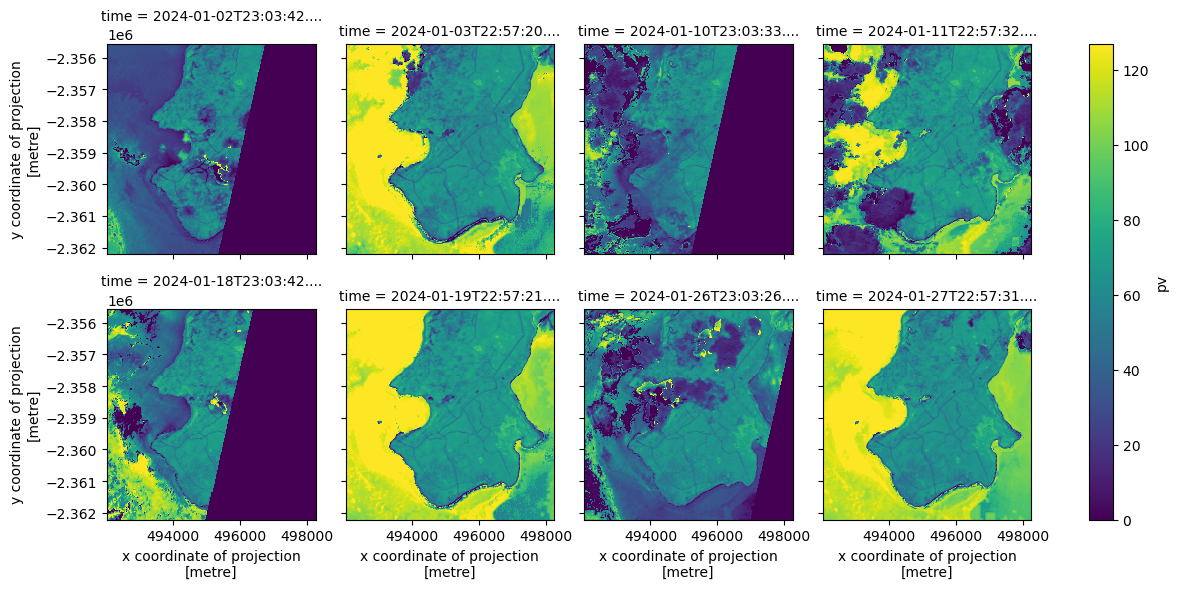

In [29]:
jan_data = clean_data.sel(time=clean_data.time.dt.month == 1)
jan_data = jan_data['pv']

dep.visualise(jan_data)

In plots 1, 3, 5, and 7, only a small portion of the image intersects with the Area of Interest (AOI); the rest of the image appears almost entirely dark. These images can be excluded from the dataset. Additionally, plot 4 shows nearly complete cloud cover, so this image should also be removed. 

In [35]:
print(clean_data)

<xarray.Dataset> Size: 16MB
Dimensions:      (time: 88, y: 222, x: 208)
Coordinates:
  * y            (y) float64 2kB -2.356e+06 -2.356e+06 ... -2.362e+06 -2.362e+06
  * x            (x) float64 2kB 4.92e+05 4.921e+05 ... 4.982e+05 4.982e+05
  * time         (time) datetime64[ns] 704B 2024-01-02T23:03:42.626943 ... 20...
    spatial_ref  int64 8B 0
Data variables:
    bs           (time, y, x) uint8 4MB dask.array<chunksize=(1, 222, 208), meta=np.ndarray>
    pv           (time, y, x) uint8 4MB dask.array<chunksize=(1, 222, 208), meta=np.ndarray>
    ue           (time, y, x) uint8 4MB dask.array<chunksize=(1, 222, 208), meta=np.ndarray>
    npv          (time, y, x) uint8 4MB dask.array<chunksize=(1, 222, 208), meta=np.ndarray>


In [38]:
minx = central_lon - buffer
maxx = central_lon + buffer
miny = central_lat - buffer
maxy = central_lat + buffer

gdf_wgs84 = gpd.GeoDataFrame({'geometry': [bbox_geometry]}, crs='EPSG:4326')

# clip the dry forest shapefile and reproject it
foret = gpd.read_file("Cartographie_des_forêts_sèches_de_Nouvelle-Calédonie_(zone_de_vigilance).shp")
if foret.crs != "EPSG:4326":
    foret = foret.to_crs("EPSG:4326")

foret_clipped = gpd.clip(foret, gdf_wgs84)

mask_crs = clean_data.rio.crs  
foret_clipped_proj = foret_clipped.to_crs(mask_crs)
gdf_proj = gdf_wgs84.to_crs(mask_crs)

# Crop valid_mask to the bounding box 
minx_proj, miny_proj, maxx_proj, maxy_proj = gdf_proj.total_bounds

valid_mask_cropped = valid_mask.sel(
    x=slice(minx_proj, maxx_proj),
    y=slice(maxy_proj, miny_proj)  # Y might go top to bottom
)

# Rasterize the reprojected forest polygons 
res_x = valid_mask_cropped['x'].values[1] - valid_mask_cropped['x'].values[0]
res_y = valid_mask_cropped['y'].values[1] - valid_mask_cropped['y'].values[0]

transform = Affine.translation(
    valid_mask_cropped['x'].values[0] - res_x / 2,
    valid_mask_cropped['y'].values[0] - res_y / 2
) * Affine.scale(res_x, res_y)

forest_mask = rasterize(
    [(geom, 1) for geom in foret_clipped_proj.geometry],
    out_shape=valid_mask_cropped.shape,
    transform=transform,
    fill=0,
    dtype='uint8'
).astype(bool)


fig, ax = plt.subplots(figsize=(10, 8))

extent = [
    valid_mask_cropped['x'].values.min(), valid_mask_cropped['x'].values.max(),
    valid_mask_cropped['y'].values.min(), valid_mask_cropped['y'].values.max()
]

# Plot all detected pixels (similar to Cluster 0)
im = ax.imshow(valid_mask_cropped.values, extent=extent, origin='upper', cmap='Blues', alpha=0.7)
plt.colorbar(im, ax=ax, label='Similarity to Cluster 0 (True = 1)')

# Overlay dry forest boundaries
foret_clipped_proj.boundary.plot(ax=ax, edgecolor='black', linewidth=1.2)
gdf_proj.boundary.plot(ax=ax, color='red', linestyle='--', linewidth=1)

ax.set_title("Detected Pixels Similar to Cluster 0", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

#  Count inside/outside detections 
inside_forest = valid_mask_cropped.values & forest_mask
outside_forest = valid_mask_cropped.values & ~forest_mask

print("Pixels similar to Cluster 0:")
print(f"   - Inside dry forest polygons:   {inside_forest.sum()}")
print(f"   - Outside dry forest polygons:  {outside_forest.sum()}")


AttributeError: 'numpy.ndarray' object has no attribute 'sel'

## 3) Agricultural landscapes - Vanuatu

The goal in this part is to see if FC allow to segment crops and detect type or stage of crops. 

In [ ]:
central_lat =-15.449810587286171
central_lon =   167.19312739727673
buffer = 0.02


lower_left = (central_lat - buffer, central_lon - buffer)
upper_right = (central_lat + buffer, central_lon + buffer)

bbox = (lower_left[1], lower_left[0], upper_right[1], upper_right[0])
bbox_geometry =geometry.box(*bbox)

gdf = gpd.GeoDataFrame({'geometry': [bbox_geometry]}, crs='EPSG:4326')
gdf.explore()

In [ ]:
items = client.search(collections=["dep_ls_fc"], bbox=bbox).item_collection()
print(f"Found {len(items)} items")

In [ ]:
items = client.search(
    collections=["dep_ls_fc"],
    bbox=bbox,
).items()
chunks = dict(x=2048, y=2048)

# Load the data
data = load(items, chunks=chunks)
data = dep.do_coastal_clip(gdf, data, buffer=0.001)
print(data)

In [ ]:
band = data['bs']
fraction_255 = (band == 255).mean(dim=['x', 'y'])
mask_95_percent = fraction_255 >= 0.95
clean_data = data.sel(time=~mask_95_percent)

band = clean_data['pv']
fraction_255 = (band == 0).mean(dim=['x', 'y'])
mask_95_percent = fraction_255 > 0.1
clean_data = clean_data.sel(time=~mask_95_percent)

band = clean_data['pv']
fraction_nans = band.isnull().mean(dim=['x', 'y'])
mask_95_percent = fraction_nans > 0.1
clean_data = clean_data.sel(time=~mask_95_percent)

clean_data = clean_data.where(clean_data != 255, 0)
print(clean_data)

In [ ]:
jan_data = clean_data.sel(time=clean_data.time.dt.month == 1)
jan_data = jan_data['pv']

dep.visualise(jan_data)

In [ ]:
# Create RGB composite imagery
data = clean_data
data = data.where(data != 255, 0)

monthly_bs = ((data['bs'] / 255) * 100).groupby(data.time.dt.month).median(dim='time')
monthly_pv = ((data['pv'] / 255) * 100).groupby(data.time.dt.month).median(dim='time')
monthly_npv = ((data['npv'] / 255) * 100).groupby(data.time.dt.month).median(dim='time')

monthly_bands = [monthly_bs, monthly_pv, monthly_npv]
band_titles = ['BS (Bare Soil)', 'PV (Photosynthetic Veg)', 'NPV (Non-Photosynthetic Veg)']

available_months = monthly_bs['month'].values


fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 10))
axes = axes.flatten()

for i, month in enumerate(range(1, 13)):
    ax = axes[i]
    if month in available_months:
        bs = monthly_bs.sel(month=month) / 100.0
        pv = monthly_pv.sel(month=month) / 100.0
        npv = monthly_npv.sel(month=month) / 100.0

        # Stack into RGB
        rgb_img = np.dstack([bs, pv, npv])
        rgb_img = np.clip(rgb_img, 0, 1)

        ax.imshow(rgb_img)
        ax.set_title(f"Month {month}", fontsize=10)
    else:
        ax.set_visible(False)

    ax.axis('off')

legend_patches = [
    Patch.Patch(color='red', label='Bare Soil (BS)'),
    Patch.Patch(color='green', label='Photosynthetic Veg (PV)'),
    Patch.Patch(color='blue', label='Non-Photosynthetic Veg (NPV)')
]

fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=12, frameon=False)

plt.suptitle("Monthly Fractional Cover RGB Composites", fontsize=16)
plt.tight_layout(rect=[0, 0.05, 1, 0.95]) 
plt.show()


In [ ]:
# --- Parameters ---
month = 1 # Choose the month
k = 4 # Number of clusters

# --- Prepare Data ---
data = clean_data.where(clean_data != 255, 0)

selected_date = np.datetime64("2024-10-01")
image = data.sel(time=selected_date,  method='nearest')

bs_m = (image['bs']/255 )
pv_m = (image['pv']/255 )
npv_m = (image['npv'] /255)

# RGB composite
rgb_img = np.dstack([bs_m, pv_m, npv_m])
rgb_img = np.clip(rgb_img, 0, 1)

# Flatten and cluster
h, w, c = rgb_img.shape
flat_rgb = rgb_img.reshape(-1, 3)
valid_mask = ~np.isnan(flat_rgb).any(axis=1)
rgb_valid = flat_rgb[valid_mask]

kmeans = KMeans(n_clusters=k, random_state=42)
labels = np.full(flat_rgb.shape[0], np.nan)
labels[valid_mask] = kmeans.fit_predict(rgb_valid)
label_img = labels.reshape(h, w)

# Plot RGB + Clusters 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


axes[0].imshow(rgb_img)
axes[0].set_title(f'Month {month} - RGB Composite')
axes[0].axis('off')

fixed_colors = [
    'aliceblue', '#4363d8', '#f58231', '#3cb44b', '#e6194b',
    '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe'
]

cluster_cmap = ListedColormap(fixed_colors[:k])
axes[1].imshow(label_img, cmap=cluster_cmap)
axes[1].set_title(f'Month {month} - KMeans Clusters (k={k})')
axes[1].axis('off')

legend_elements = [
    Patch.Patch(facecolor=cluster_cmap(i), edgecolor='black', label=f'Cluster {i}')
    for i in range(k)
]
axes[1].legend(handles=legend_elements, loc='upper left', title='Clusters')
plt.tight_layout()
plt.show()


# Plot Cluster Pixel Distribution 
fig, axes = plt.subplots(nrows=int(np.ceil(k / 3)), ncols=3, figsize=(15, 3 * int(np.ceil(k / 3))))
axes = axes.flatten()

for cl in range(k):
    mask = label_img == cl

    bs_vals = bs_m.values[mask]
    pv_vals = pv_m.values[mask]
    npv_vals = npv_m.values[mask]

    ax = axes[cl]
    ax.hist(bs_vals, bins=20, alpha=0.6, label='BS', color='saddlebrown')
    ax.hist(pv_vals, bins=20, alpha=0.6, label='PV', color='green')
    ax.hist(npv_vals, bins=20, alpha=0.6, label='NPV', color='orange')
    ax.set_title(f'Cluster {cl}')
    ax.legend()

plt.suptitle(f'Pixel Value Distribution per Cluster — Month {month}', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

ScreenShot from google maps :

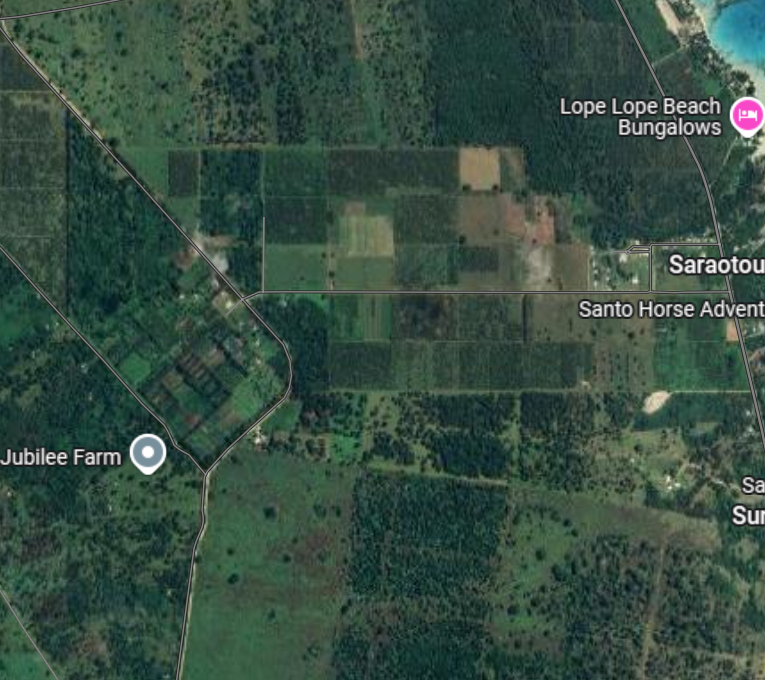

Cluster 3 seems to be coconut trees, cluster 0 building area, cluster 1 denser forest or grass land. Analyzing timeseries of NDVI for the area and combining it with FC data and spectral data to train a RF classifiers is a good method to perform crop classification